# PPO for Continuous Control Robotics

## Project Overview

This project implements the Proximal Policy Optimization (PPO) algorithm for a continuous-control robotics task using the MuJoCo `Reacher-v5` environment provided by Gymnasium.

The objective of the agent is to control a two-joint robotic arm so that its fingertip moves toward a target position. Because the robot's actions are continuous, the actor network represents the policy using a continuous probability distribution.

The project implements the major components of PPO, including:

- Actor-Critic neural networks
- Gaussian continuous-action policy
- PPO clipped surrogate objective
- Generalized Advantage Estimation (GAE)
- Advantage normalization
- Mini-batch optimization
- Multiple training epochs per PPO update
- Training and evaluation metrics

## 1. Environment and Library Setup

The project uses Gymnasium to provide the reinforcement learning environment and MuJoCo as the physics simulator.

PyTorch is used to construct and optimize the actor-critic neural networks.

The following cell imports the required libraries and records their versions so that the implementation environment can be reproduced and verified.

In [1]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
import mujoco

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

print("Python environment successfully initialized.")
print(f"Gymnasium version : {gym.__version__}")
print(f"MuJoCo version    : {mujoco.__version__}")
print(f"PyTorch version   : {torch.__version__}")
print(f"CUDA available    : {torch.cuda.is_available()}")

Python environment successfully initialized.
Gymnasium version : 1.3.0
MuJoCo version    : 3.11.0
PyTorch version   : 2.10.0+cpu
CUDA available    : False


## 2. Create and Inspect the Reacher-v5 Environment

The `Reacher-v5` environment represents a two-joint robotic arm that must move its fingertip toward a target.

Before implementing PPO, it is important to inspect the observation space, action space, and initial state returned by the environment. This confirms the dimensions that the actor and critic neural networks must use.

In [2]:
env = gym.make("Reacher-v5")

observation_space = env.observation_space
action_space = env.action_space

observation_dim = observation_space.shape[0]
action_dim = action_space.shape[0]

print("Environment created successfully.")
print(f"Environment ID      : {env.spec.id}")
print(f"Observation space   : {observation_space}")
print(f"Observation dimension: {observation_dim}")
print(f"Action space        : {action_space}")
print(f"Action dimension    : {action_dim}")
print(f"Action lower bounds : {action_space.low}")
print(f"Action upper bounds : {action_space.high}")

Environment created successfully.
Environment ID      : Reacher-v5
Observation space   : Box(-inf, inf, (10,), float64)
Observation dimension: 10
Action space        : Box(-1.0, 1.0, (2,), float32)
Action dimension    : 2
Action lower bounds : [-1. -1.]
Action upper bounds : [1. 1.]


In [3]:
state, info = env.reset(seed=42)

random_action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(random_action)

print("Initial state:")
print(state)

print("\nState shape:")
print(state.shape)

print("\nRandom action:")
print(random_action)

print("\nAction shape:")
print(random_action.shape)

print("\nReward:")
print(reward)

print("\nNext state shape:")
print(next_state.shape)

print("\nTerminated:", terminated)
print("Truncated :", truncated)

Initial state:
[ 9.98499337e-01  9.99925284e-01  5.47637993e-02 -1.22240076e-02
  1.04455881e-01  1.14425722e-01 -3.71886367e-03 -4.96140621e-04
  1.05294411e-01 -1.04268397e-01]

State shape:
(10,)

Random action:
[-0.0279509 -0.9964501]

Action shape:
(2,)

Reward:
-1.1452226468008575

Next state shape:
(10,)

Terminated: False
Truncated : False


## 3. Actor-Critic Architecture

PPO uses an actor-critic architecture.

The actor learns the policy used to select continuous actions for the robot. It receives the current observation and produces the parameters needed to construct a continuous action distribution.

The critic receives the same observation and estimates the value of the current state, represented as V(s).

In this project:

- Actor input: 10 observation values
- Actor output: policy for 2 continuous actions
- Critic input: 10 observation values
- Critic output: 1 state-value estimate

### Gaussian Policy for Continuous Actions

Because the Reacher environment uses continuous actions, the actor represents its policy using Gaussian probability distributions.

For each action dimension, the policy defines a mean and standard deviation. The mean represents the preferred action, while the standard deviation controls the amount of exploration.

Actions can then be sampled from these distributions during training.

In [4]:
mean = torch.tensor([0.40, -0.25])
std = torch.tensor([0.20, 0.30])

distribution = Normal(mean, std)

sampled_action = distribution.sample()

print("Mean:")
print(mean)

print("\nStandard deviation:")
print(std)

print("\nSampled action:")
print(sampled_action)

Mean:
tensor([ 0.4000, -0.2500])

Standard deviation:
tensor([0.2000, 0.3000])

Sampled action:
tensor([0.4436, 0.4869])


### Action Log-Probability

PPO needs to measure how likely a selected action is under the current policy.

For continuous Gaussian policies, the log-probability of an action can be calculated from the action distribution. PPO later compares log-probabilities from the old and updated policies to determine how much the policy has changed.

In [5]:
mean = torch.tensor([0.40, -0.25])
std = torch.tensor([0.20, 0.30])

distribution = Normal(mean, std)

sampled_action = distribution.sample()

log_prob_each = distribution.log_prob(sampled_action)
total_log_prob = log_prob_each.sum()

print("Sampled action:")
print(sampled_action)

print("\nLog-probability of each action dimension:")
print(log_prob_each)

print("\nTotal log-probability:")
print(total_log_prob)

Sampled action:
tensor([ 0.6945, -0.3308])

Log-probability of each action dimension:
tensor([-0.3936,  0.2488])

Total log-probability:
tensor(-0.1449)


### Actor-Critic Neural Network

The PPO agent uses separate actor and critic neural networks.

The actor receives the 10-dimensional environment observation and produces the mean of a Gaussian policy for the two continuous actions. A learnable log-standard-deviation parameter controls policy exploration.

The critic receives the same observation and produces a single state-value estimate, V(s).

Both networks use two hidden layers with 64 neurons and Tanh activation functions.

In [6]:
class ActorCritic(nn.Module):
    def __init__(self, observation_dim, action_dim, hidden_size=64):
        super().__init__()

        # Actor network: state -> preferred action means
        self.actor = nn.Sequential(
            nn.Linear(observation_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, action_dim)
        )

        # Learnable exploration parameter for each action dimension
        self.actor_log_std = nn.Parameter(
            torch.zeros(action_dim)
        )

        # Critic network: state -> state value
        self.critic = nn.Sequential(
            nn.Linear(observation_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, state):
        action_mean = self.actor(state)

        action_std = torch.exp(self.actor_log_std)

        state_value = self.critic(state)

        return action_mean, action_std, state_value

In [7]:
model = ActorCritic(
    observation_dim=observation_dim,
    action_dim=action_dim
)

print(model)

ActorCritic(
  (actor): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Test the Actor-Critic Network

A real observation from the Reacher environment is passed through the actor-critic model.

The actor produces the mean and standard deviation of the Gaussian action policy, while the critic produces an estimate of the current state's value.

This verifies that the model dimensions and outputs are compatible with the environment.

In [8]:
state, info = env.reset(seed=42)

state_tensor = torch.tensor(
    state,
    dtype=torch.float32
)

action_mean, action_std, state_value = model(state_tensor)

print("State tensor shape:")
print(state_tensor.shape)

print("\nActor action mean:")
print(action_mean)

print("\nActor action standard deviation:")
print(action_std)

print("\nCritic state value:")
print(state_value)

State tensor shape:
torch.Size([10])

Actor action mean:
tensor([-0.0253, -0.1203], grad_fn=<ViewBackward0>)

Actor action standard deviation:
tensor([1., 1.], grad_fn=<ExpBackward0>)

Critic state value:
tensor([-0.3000], grad_fn=<ViewBackward0>)


### Sampling a Continuous Robot Action

The actor defines a Gaussian distribution using its predicted action means and learned standard deviations.

An action is first sampled from this Gaussian distribution. Because Gaussian samples are unbounded while the Reacher action space is limited to values between -1 and 1, the hyperbolic tangent (`tanh`) function is applied to produce a valid bounded action.

In [9]:
state, info = env.reset(seed=42)

state_tensor = torch.tensor(
    state,
    dtype=torch.float32
)

with torch.no_grad():
    action_mean, action_std, state_value = model(state_tensor)

    distribution = Normal(action_mean, action_std)

    raw_action = distribution.sample()

    bounded_action = torch.tanh(raw_action)

print("Actor mean:")
print(action_mean)

print("\nActor standard deviation:")
print(action_std)

print("\nRaw Gaussian action:")
print(raw_action)

print("\nBounded action after tanh:")
print(bounded_action)

print("\nValid Reacher action range:")
print("Minimum:", bounded_action.min().item())
print("Maximum:", bounded_action.max().item())

Actor mean:
tensor([-0.0253, -0.1203])

Actor standard deviation:
tensor([1., 1.])

Raw Gaussian action:
tensor([-0.6205,  1.0103])

Bounded action after tanh:
tensor([-0.5515,  0.7659])

Valid Reacher action range:
Minimum: -0.5514962077140808
Maximum: 0.7658798098564148


### Execute an Actor-Generated Action

The bounded action produced by the actor is converted from a PyTorch tensor to a NumPy array and passed to the Reacher environment.

The environment then returns the next observation, reward, and episode status. This completes one full interaction between the PPO policy and the robotics environment.

In [10]:
state, info = env.reset(seed=42)

state_tensor = torch.tensor(
    state,
    dtype=torch.float32
)

with torch.no_grad():

    # Actor and critic process the current state
    action_mean, action_std, state_value = model(state_tensor)

    # Build the Gaussian policy
    distribution = Normal(action_mean, action_std)

    # Sample an action
    raw_action = distribution.sample()

    # Restrict the action to the valid [-1, 1] range
    bounded_action = torch.tanh(raw_action)

# MuJoCo expects a NumPy array rather than a PyTorch tensor
action_numpy = bounded_action.numpy()

# Execute the action in the robot environment
next_state, reward, terminated, truncated, info = env.step(action_numpy)

print("Current state shape:")
print(state.shape)

print("\nActor-generated action:")
print(action_numpy)

print("\nReward received:")
print(reward)

print("\nNext state shape:")
print(next_state.shape)

print("\nTerminated:", terminated)
print("Truncated :", truncated)

Current state shape:
(10,)

Actor-generated action:
[-0.4616838 -0.3117039]

Reward received:
-0.4623360397893438

Next state shape:
(10,)

Terminated: False
Truncated : False


In [11]:
state, info = env.reset(seed=42)

state_tensor = torch.tensor(
    state,
    dtype=torch.float32
)

with torch.no_grad():

    # Actor and critic process the current state
    action_mean, action_std, state_value = model(state_tensor)

    # Build the Gaussian policy
    distribution = Normal(action_mean, action_std)

    # Sample an action
    raw_action = distribution.sample()

    # Restrict the action to the valid [-1, 1] range
    bounded_action = torch.tanh(raw_action)

# MuJoCo expects a NumPy array rather than a PyTorch tensor
action_numpy = bounded_action.numpy()

# Execute the action in the robot environment
next_state, reward, terminated, truncated, info = env.step(action_numpy)

print("Current state shape:")
print(state.shape)

print("\nActor-generated action:")
print(action_numpy)

print("\nReward received:")
print(reward)

print("\nNext state shape:")
print(next_state.shape)

print("\nTerminated:", terminated)
print("Truncated :", truncated)

Current state shape:
(10,)

Actor-generated action:
[0.7949322 0.5436998]

Reward received:
-1.0690908118349052

Next state shape:
(10,)

Terminated: False
Truncated : False


## 4. Collecting Rollout Experience

PPO is an on-policy reinforcement learning algorithm. The agent first interacts with the environment using its current policy and collects a sequence of experiences called a rollout.

Each interaction provides information such as the current state, selected action, received reward, and resulting next state.

The collected rollout will later be used to calculate returns, advantages, and PPO updates.

In [12]:
state, info = env.reset(seed=42)

rollout_states = []
rollout_actions = []
rollout_rewards = []

for step in range(5):

    # Convert current environment state to PyTorch
    state_tensor = torch.tensor(
        state,
        dtype=torch.float32
    )

    # Actor selects an action
    with torch.no_grad():

        action_mean, action_std, state_value = model(state_tensor)

        distribution = Normal(action_mean, action_std)

        raw_action = distribution.sample()

        bounded_action = torch.tanh(raw_action)

    # Convert action to NumPy for MuJoCo
    action_numpy = bounded_action.numpy()

    # Execute the action
    next_state, reward, terminated, truncated, info = env.step(action_numpy)

    # Store the experience
    rollout_states.append(state)
    rollout_actions.append(action_numpy)
    rollout_rewards.append(reward)

    print(
        f"Step {step + 1}: "
        f"Action={action_numpy}, "
        f"Reward={reward:.4f}"
    )

    # Move to the next state
    state = next_state

    # Reset if episode ends
    if terminated or truncated:
        state, info = env.reset()

Step 1: Action=[-0.27788797  0.76968545], Reward=-0.8171
Step 2: Action=[-0.6895165  -0.06025736], Reward=-0.6293
Step 3: Action=[-0.9657672  0.2687257], Reward=-1.1672
Step 4: Action=[0.87597954 0.72067624], Reward=-1.4576
Step 5: Action=[-0.8180224  0.9468096], Reward=-1.7380


### Inspect the Collected Rollout

The rollout stores a sequence of states, actions, and rewards generated by the current policy.

Before using this data for PPO training, the collected values are converted into NumPy arrays so their dimensions can be verified.

In [13]:
rollout_states_array = np.array(rollout_states)
rollout_actions_array = np.array(rollout_actions)
rollout_rewards_array = np.array(rollout_rewards)

print("Rollout states shape:")
print(rollout_states_array.shape)

print("\nRollout actions shape:")
print(rollout_actions_array.shape)

print("\nRollout rewards shape:")
print(rollout_rewards_array.shape)

print("\nRewards:")
print(rollout_rewards_array)

Rollout states shape:
(5, 10)

Rollout actions shape:
(5, 2)

Rollout rewards shape:
(5,)

Rewards:
[-0.81706104 -0.62930819 -1.16719725 -1.45759522 -1.7380186 ]


### Store Value Estimates and Action Log-Probabilities

PPO requires additional information from the policy during rollout collection.

For each state, the critic estimates the state value, while the actor provides the log-probability of the selected action. The old action log-probability will later be compared with the updated policy during the PPO clipped update.

Because actions are passed through `tanh` to satisfy the environment's action bounds, the action log-probability includes the corresponding transformation correction.

In [14]:
state, info = env.reset(seed=42)

rollout_states = []
rollout_actions = []
rollout_raw_actions = []
rollout_rewards = []
rollout_values = []
rollout_log_probs = []

for step in range(5):

    state_tensor = torch.tensor(
        state,
        dtype=torch.float32
    )

    with torch.no_grad():

        # Get Actor and Critic outputs
        action_mean, action_std, state_value = model(state_tensor)

        # Create Gaussian policy
        distribution = Normal(action_mean, action_std)

        # Sample raw action
        raw_action = distribution.sample()

        # Bound action to [-1, 1]
        bounded_action = torch.tanh(raw_action)

        # Gaussian log-probability
        log_prob = distribution.log_prob(raw_action)

        # Correct log-probability for tanh transformation
        log_prob -= torch.log(
            1 - bounded_action.pow(2) + 1e-6
        )

        # Combine the two action dimensions
        log_prob = log_prob.sum()

    action_numpy = bounded_action.numpy()

    next_state, reward, terminated, truncated, info = env.step(
        action_numpy
    )

    # Store rollout information
    rollout_states.append(state)
    rollout_actions.append(action_numpy)
    rollout_raw_actions.append(raw_action.numpy())
    rollout_rewards.append(reward)
    rollout_values.append(state_value.item())
    rollout_log_probs.append(log_prob.item())

    print(
        f"Step {step + 1}: "
        f"Reward={reward:.4f}, "
        f"Value={state_value.item():.4f}, "
        f"LogProb={log_prob.item():.4f}"
    )

    state = next_state

    if terminated or truncated:
        state, info = env.reset()

Step 1: Reward=-1.1479, Value=-0.3000, LogProb=-0.9689
Step 2: Reward=-0.4015, Value=-0.1035, LogProb=-1.5841
Step 3: Reward=-1.1214, Value=-0.2182, LogProb=-0.4731
Step 4: Reward=-1.3605, Value=-0.2971, LogProb=-0.4690
Step 5: Reward=-1.7718, Value=-0.3060, LogProb=-0.2279


## 5. Advantage Estimation

The advantage estimates whether an action produced an outcome that was better or worse than the critic expected.

A positive advantage indicates that the action performed better than expected, while a negative advantage indicates that it performed worse.

PPO uses Generalized Advantage Estimation (GAE) to combine temporal-difference information across multiple timesteps and produce a more stable estimate of advantage.

### One-Step Temporal-Difference Error

Before calculating Generalized Advantage Estimation, a single temporal-difference (TD) error is examined.

The TD error compares the reward and estimated value of the next state with the critic's estimate of the current state.

A positive TD error indicates an outcome better than expected, while a negative TD error indicates an outcome worse than expected.

In [15]:
gamma = 0.99

reward_t = rollout_rewards[0]
value_t = rollout_values[0]
next_value = rollout_values[1]

td_error = (
    reward_t
    + gamma * next_value
    - value_t
)

print(f"Reward at Step 1       : {reward_t:.4f}")
print(f"Current state value    : {value_t:.4f}")
print(f"Next state value       : {next_value:.4f}")
print(f"Discount factor gamma  : {gamma}")
print(f"TD error               : {td_error:.4f}")

Reward at Step 1       : -1.1479
Current state value    : -0.3000
Next state value       : -0.1035
Discount factor gamma  : 0.99
TD error               : -0.9504


### Generalized Advantage Estimation

Generalized Advantage Estimation (GAE) improves the advantage estimate by combining temporal-difference errors across multiple future timesteps.

The discount factor gamma determines how future rewards are discounted, while GAE lambda determines how strongly future temporal-difference errors influence the current advantage.

GAE is calculated backward through the collected rollout so that information from later transitions contributes to earlier advantage estimates.

In [16]:
gamma = 0.99
gae_lambda = 0.95

rewards = np.array(rollout_rewards, dtype=np.float32)
values = np.array(rollout_values, dtype=np.float32)

advantages = np.zeros_like(rewards)

gae = 0.0

for t in reversed(range(len(rewards))):

    if t == len(rewards) - 1:
        next_value = 0.0
    else:
        next_value = values[t + 1]

    td_error = (
        rewards[t]
        + gamma * next_value
        - values[t]
    )

    gae = (
        td_error
        + gamma * gae_lambda * gae
    )

    advantages[t] = gae

print("Rewards:")
print(rewards)

print("\nCritic values:")
print(values)

print("\nGAE advantages:")
print(advantages)

Rewards:
[-1.1478617  -0.40147167 -1.1214088  -1.3604928  -1.7717841 ]

Critic values:
[-0.30000025 -0.10352817 -0.218227   -0.29707986 -0.30597317]

GAE advantages:
[-4.77634   -4.0680337 -3.7788897 -2.7449214 -1.4658109]


Learning rate        = 3e-4
Gamma                = 0.99
GAE lambda           = 0.95
PPO clip range       = 0.20
Rollout size         = 1024 steps
Mini-batch size      = 64
PPO epochs/update    = 10
Entropy coefficient  = 0.01
Value coefficient    = 0.50
Gradient clipping    = 0.50

## 6. PPO Hyperparameters

The PPO training process is controlled by several hyperparameters.

The discount factor and GAE lambda determine how future information contributes to learning. The PPO clipping range limits large policy updates, while the rollout size, mini-batch size, and number of optimization epochs determine how collected experiences are reused during training.

Additional coefficients control entropy-based exploration, critic learning, and gradient stability.

In [17]:
learning_rate = 3e-4

gamma = 0.99
gae_lambda = 0.95

clip_epsilon = 0.20

rollout_steps = 1024
batch_size = 64
ppo_epochs = 10

entropy_coef = 0.01
value_coef = 0.50

max_grad_norm = 0.50

print("PPO Hyperparameters")
print("-------------------")
print(f"Learning rate       : {learning_rate}")
print(f"Gamma               : {gamma}")
print(f"GAE lambda          : {gae_lambda}")
print(f"Clip epsilon        : {clip_epsilon}")
print(f"Rollout steps       : {rollout_steps}")
print(f"Batch size          : {batch_size}")
print(f"PPO epochs          : {ppo_epochs}")
print(f"Entropy coefficient : {entropy_coef}")
print(f"Value coefficient   : {value_coef}")
print(f"Max gradient norm   : {max_grad_norm}")

PPO Hyperparameters
-------------------
Learning rate       : 0.0003
Gamma               : 0.99
GAE lambda          : 0.95
Clip epsilon        : 0.2
Rollout steps       : 1024
Batch size          : 64
PPO epochs          : 10
Entropy coefficient : 0.01
Value coefficient   : 0.5
Max gradient norm   : 0.5


## 7. PPO Clipped Surrogate Objective

PPO compares the probability of an action under the updated policy with its probability under the policy that originally collected the rollout.

The resulting probability ratio measures how much the policy has changed.

A ratio near 1 indicates little policy change. PPO uses a clipping range to prevent excessively large policy updates. With a clipping parameter of 0.2, the surrogate objective limits the incentive for the probability ratio to move too far beyond approximately 0.8 to 1.2.

The advantage determines whether the probability of an action should increase or decrease, while clipping helps keep these policy updates stable.

In [18]:
example_ratios = torch.tensor([
    0.60,
    0.90,
    1.00,
    1.10,
    1.50
])

clipped_ratios = torch.clamp(
    example_ratios,
    1 - clip_epsilon,
    1 + clip_epsilon
)

print("Original ratios:")
print(example_ratios)

print("\nClipped ratios:")
print(clipped_ratios)

print(
    f"\nAllowed clipping range: "
    f"{1 - clip_epsilon:.1f} to {1 + clip_epsilon:.1f}"
)

Original ratios:
tensor([0.6000, 0.9000, 1.0000, 1.1000, 1.5000])

Clipped ratios:
tensor([0.8000, 0.9000, 1.0000, 1.1000, 1.2000])

Allowed clipping range: 0.8 to 1.2


### PPO Policy Loss

The PPO policy objective combines the probability ratio with the estimated advantage.

Two surrogate objectives are calculated: one using the original probability ratio and another using the clipped ratio. PPO selects the more conservative objective so that excessively large policy updates do not receive additional benefit.

Because PyTorch optimizers minimize loss functions, the negative of the clipped surrogate objective is used as the policy loss.

In [19]:
example_ratios = torch.tensor([
    1.50,
    1.10,
    0.90,
    0.60
])

example_advantages = torch.tensor([
     2.0,
     2.0,
    -2.0,
    -2.0
])

surrogate1 = (
    example_ratios
    * example_advantages
)

clipped_ratios = torch.clamp(
    example_ratios,
    1 - clip_epsilon,
    1 + clip_epsilon
)

surrogate2 = (
    clipped_ratios
    * example_advantages
)

ppo_objective = torch.min(
    surrogate1,
    surrogate2
)

policy_loss = -ppo_objective.mean()

print("Ratios:")
print(example_ratios)

print("\nAdvantages:")
print(example_advantages)

print("\nUnclipped surrogate:")
print(surrogate1)

print("\nClipped surrogate:")
print(surrogate2)

print("\nPPO selected objective:")
print(ppo_objective)

print("\nPolicy loss:")
print(policy_loss)

Ratios:
tensor([1.5000, 1.1000, 0.9000, 0.6000])

Advantages:
tensor([ 2.,  2., -2., -2.])

Unclipped surrogate:
tensor([ 3.0000,  2.2000, -1.8000, -1.2000])

Clipped surrogate:
tensor([ 2.4000,  2.2000, -1.8000, -1.6000])

PPO selected objective:
tensor([ 2.4000,  2.2000, -1.8000, -1.6000])

Policy loss:
tensor(-0.3000)


### Value Loss and Entropy

PPO trains both the actor and the critic.

The critic is trained by comparing its predicted state values with target returns derived from the collected rollout. Mean squared error is used as the value loss.

The actor's Gaussian policy also provides an entropy measure. Entropy represents the amount of exploration in the policy. A small entropy bonus helps prevent the policy from becoming overly deterministic too early in training.

The final PPO loss combines the policy loss, value loss, and entropy contribution.

In [20]:
# Example critic predictions and target returns
predicted_values = torch.tensor([
    -0.5,
    -1.0,
    -1.5
])

target_returns = torch.tensor([
    -1.0,
    -0.8,
    -2.0
])

# Mean squared error for critic
value_loss = nn.functional.mse_loss(
    predicted_values,
    target_returns
)

# Example Gaussian policy entropy
example_mean = torch.tensor([0.0, 0.0])
example_std = torch.tensor([1.0, 1.0])

example_distribution = Normal(
    example_mean,
    example_std
)

entropy = example_distribution.entropy().sum()

print("Predicted values:")
print(predicted_values)

print("\nTarget returns:")
print(target_returns)

print("\nValue loss:")
print(value_loss)

print("\nPolicy entropy:")
print(entropy)

Predicted values:
tensor([-0.5000, -1.0000, -1.5000])

Target returns:
tensor([-1.0000, -0.8000, -2.0000])

Value loss:
tensor(0.1800)

Policy entropy:
tensor(2.8379)


## 8. PPO Optimization Update

The collected rollout is used to update the actor and critic networks.

Before optimization, advantages are normalized to improve numerical stability. The rollout is divided into mini-batches and reused for multiple PPO epochs.

For each mini-batch, the updated policy recomputes action log-probabilities and compares them with the old log-probabilities stored during rollout collection. The PPO clipped surrogate objective is used for the actor, mean squared error is used for the critic, and an entropy bonus encourages exploration.

Gradient clipping is applied before the optimizer updates the network parameters.

In [21]:
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

print("Optimizer created successfully.")
print(optimizer)

Optimizer created successfully.
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)


In [22]:
def ppo_update(
    model,
    optimizer,
    states,
    raw_actions,
    old_log_probs,
    returns,
    advantages,
    batch_size,
    ppo_epochs,
    clip_epsilon,
    value_coef,
    entropy_coef,
    max_grad_norm
):
    # Convert rollout data to PyTorch tensors
    states = torch.tensor(
        states,
        dtype=torch.float32
    )

    raw_actions = torch.tensor(
        raw_actions,
        dtype=torch.float32
    )

    old_log_probs = torch.tensor(
        old_log_probs,
        dtype=torch.float32
    )

    returns = torch.tensor(
        returns,
        dtype=torch.float32
    )

    advantages = torch.tensor(
        advantages,
        dtype=torch.float32
    )

    # Normalize advantages
    advantages = (
        advantages - advantages.mean()
    ) / (
        advantages.std(unbiased=False) + 1e-8
    )

    # Metrics collected during the PPO update
    policy_losses = []
    value_losses = []
    entropies = []
    clip_fractions = []

    num_samples = states.shape[0]

    # Reuse the rollout for multiple PPO epochs
    for epoch in range(ppo_epochs):

        # Randomize sample order
        indices = torch.randperm(num_samples)

        # Process rollout in mini-batches
        for start in range(0, num_samples, batch_size):

            end = start + batch_size

            batch_indices = indices[start:end]

            batch_states = states[batch_indices]
            batch_raw_actions = raw_actions[batch_indices]
            batch_old_log_probs = old_log_probs[batch_indices]
            batch_returns = returns[batch_indices]
            batch_advantages = advantages[batch_indices]

            # Current Actor and Critic predictions
            action_mean, action_std, state_values = model(
                batch_states
            )

            distribution = Normal(
                action_mean,
                action_std
            )

            # Recompute log-probability under current policy
            new_log_probs = distribution.log_prob(
                batch_raw_actions
            )

            bounded_actions = torch.tanh(
                batch_raw_actions
            )

            # Correct for tanh transformation
            new_log_probs -= torch.log(
                1 - bounded_actions.pow(2) + 1e-6
            )

            new_log_probs = new_log_probs.sum(dim=-1)

            # PPO probability ratio
            ratios = torch.exp(
                new_log_probs - batch_old_log_probs
            )

            # PPO clipped surrogate objective
            surrogate1 = (
                ratios * batch_advantages
            )

            surrogate2 = (
                torch.clamp(
                    ratios,
                    1 - clip_epsilon,
                    1 + clip_epsilon
                )
                * batch_advantages
            )

            policy_loss = -torch.min(
                surrogate1,
                surrogate2
            ).mean()

            # Critic loss
            state_values = state_values.squeeze(-1)

            value_loss = nn.functional.mse_loss(
                state_values,
                batch_returns
            )

            # Gaussian policy entropy
            entropy = distribution.entropy().sum(
                dim=-1
            ).mean()

            # Combined PPO loss
            total_loss = (
                policy_loss
                + value_coef * value_loss
                - entropy_coef * entropy
            )

            # Backpropagation
            optimizer.zero_grad()

            total_loss.backward()

            # Prevent excessively large gradients
            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_grad_norm
            )

            optimizer.step()

            # PPO stability metric:
            # fraction of samples outside clipping range
            clip_fraction = (
                (torch.abs(ratios - 1.0) > clip_epsilon)
                .float()
                .mean()
            )

            policy_losses.append(policy_loss.item())
            value_losses.append(value_loss.item())
            entropies.append(entropy.item())
            clip_fractions.append(clip_fraction.item())

    return {
        "policy_loss": np.mean(policy_losses),
        "value_loss": np.mean(value_losses),
        "entropy": np.mean(entropies),
        "clip_fraction": np.mean(clip_fractions)
    }

### Validate the PPO Update Function

Before starting full training, the PPO update procedure is tested using the small five-step rollout collected earlier.

The target return for each state is calculated as the critic value plus the estimated advantage.

A copy of the actor-critic model is used for this validation so that the main model remains unchanged.

In [23]:
import copy

# PPO target returns
returns = advantages + values

print("Advantages:")
print(advantages)

print("\nTarget returns:")
print(returns)

# Make a copy so this test does not modify the main model
test_model = copy.deepcopy(model)

test_optimizer = optim.Adam(
    test_model.parameters(),
    lr=learning_rate
)

# Run a small PPO update test
test_metrics = ppo_update(
    model=test_model,
    optimizer=test_optimizer,
    states=np.array(rollout_states),
    raw_actions=np.array(rollout_raw_actions),
    old_log_probs=np.array(rollout_log_probs),
    returns=returns,
    advantages=advantages,
    batch_size=5,
    ppo_epochs=2,
    clip_epsilon=clip_epsilon,
    value_coef=value_coef,
    entropy_coef=entropy_coef,
    max_grad_norm=max_grad_norm
)

print("\nPPO update test completed successfully.")

print(f"Policy loss   : {test_metrics['policy_loss']:.6f}")
print(f"Value loss    : {test_metrics['value_loss']:.6f}")
print(f"Entropy       : {test_metrics['entropy']:.6f}")
print(f"Clip fraction : {test_metrics['clip_fraction']:.6f}")

Advantages:
[-4.77634   -4.0680337 -3.7788897 -2.7449214 -1.4658109]

Target returns:
[-5.07634   -4.1715617 -3.9971166 -3.0420012 -1.7717841]

PPO update test completed successfully.
Policy loss   : -0.022301
Value loss    : 12.558571
Entropy       : 2.838177
Clip fraction : 0.000000


## 9. Full Rollout Collection and GAE

The training rollout function collects a fixed number of transitions using the current PPO policy.

For every interaction, the function stores the state, raw Gaussian action, action log-probability, reward, critic value estimate, and episode-boundary information.

After rollout collection, Generalized Advantage Estimation is calculated backward through the stored transitions. The critic's estimate of the next state is used for bootstrapping when appropriate.

The function also tracks completed episode rewards so that learning progress can be monitored during training.

In [26]:
def collect_rollout(
    env,
    model,
    state,
    episode_reward,
    rollout_steps,
    gamma,
    gae_lambda
):
    states = []
    raw_actions = []
    log_probs = []
    rewards = []
    values = []
    next_values = []
    continuation_masks = []

    completed_episode_rewards = []

    for step in range(rollout_steps):

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        )

        with torch.no_grad():

            # Actor and Critic evaluate current state
            action_mean, action_std, state_value = model(
                state_tensor
            )

            # Gaussian policy
            distribution = Normal(
                action_mean,
                action_std
            )

            # Sample continuous action
            raw_action = distribution.sample()

            # Bound action to [-1, 1]
            bounded_action = torch.tanh(raw_action)

            # Log-probability of sampled action
            log_prob = distribution.log_prob(
                raw_action
            )

            # Tanh correction
            log_prob -= torch.log(
                1 - bounded_action.pow(2) + 1e-6
            )

            log_prob = log_prob.sum()

        action_numpy = bounded_action.numpy()

        # Execute action
        next_state, reward, terminated, truncated, info = env.step(
            action_numpy
        )

        episode_done = terminated or truncated

        # Estimate value of next state
        next_state_tensor = torch.tensor(
            next_state,
            dtype=torch.float32
        )

        with torch.no_grad():

            _, _, next_state_value = model(
                next_state_tensor
            )

        # True termination has no future value.
        # Time-limit truncation can bootstrap.
        bootstrap_next_value = (
            0.0
            if terminated
            else next_state_value.item()
        )

        # Store transition
        states.append(state.copy())
        raw_actions.append(raw_action.numpy())
        log_probs.append(log_prob.item())
        rewards.append(reward)
        values.append(state_value.item())
        next_values.append(bootstrap_next_value)

        # Stop GAE from crossing episode boundaries
        continuation_masks.append(
            0.0 if episode_done else 1.0
        )

        episode_reward += reward

        # Reset after completed episode
        if episode_done:

            completed_episode_rewards.append(
                episode_reward
            )

            episode_reward = 0.0

            state, info = env.reset()

        else:

            state = next_state

    # Convert rollout data to arrays
    states = np.array(states, dtype=np.float32)

    raw_actions = np.array(
        raw_actions,
        dtype=np.float32
    )

    old_log_probs = np.array(
        log_probs,
        dtype=np.float32
    )

    rewards = np.array(
        rewards,
        dtype=np.float32
    )

    values = np.array(
        values,
        dtype=np.float32
    )

    next_values = np.array(
        next_values,
        dtype=np.float32
    )

    continuation_masks = np.array(
        continuation_masks,
        dtype=np.float32
    )

    # Generalized Advantage Estimation
    advantages = np.zeros_like(
        rewards,
        dtype=np.float32
    )

    gae = 0.0

    for t in reversed(range(rollout_steps)):

        td_error = (
            rewards[t]
            + gamma * next_values[t]
            - values[t]
        )

        gae = (
            td_error
            + gamma
            * gae_lambda
            * continuation_masks[t]
            * gae
        )

        advantages[t] = gae

    # Critic targets
    returns = advantages + values

    return {
        "states": states,
        "raw_actions": raw_actions,
        "old_log_probs": old_log_probs,
        "advantages": advantages,
        "returns": returns,
        "rewards": rewards,
        "values": values,
        "completed_episode_rewards": completed_episode_rewards,
        "next_state": state,
        "episode_reward": episode_reward
    }

In [28]:
test_state, info = env.reset(seed=42)
test_episode_reward = 0.0

test_rollout = collect_rollout(
    env=env,
    model=model,
    state=test_state,
    episode_reward=test_episode_reward,
    rollout_steps=128,
    gamma=gamma,
    gae_lambda=gae_lambda
)

print("Rollout collection successful.")

print(
    "States shape       :",
    test_rollout["states"].shape
)

print(
    "Raw actions shape  :",
    test_rollout["raw_actions"].shape
)

print(
    "Old log-probs shape:",
    test_rollout["old_log_probs"].shape
)

print(
    "Advantages shape   :",
    test_rollout["advantages"].shape
)

print(
    "Returns shape      :",
    test_rollout["returns"].shape
)

print(
    "\nCompleted episodes :",
    len(test_rollout["completed_episode_rewards"])
)

print(
    "Partial episode reward:",
    test_rollout["episode_reward"]
)

Rollout collection successful.
States shape       : (128, 10)
Raw actions shape  : (128, 2)
Old log-probs shape: (128,)
Advantages shape   : (128,)
Returns shape      : (128,)

Completed episodes : 2
Partial episode reward: -31.391423710132223


## 10. PPO Training Loop

The full PPO training loop alternates between experience collection and policy optimization.

During each update, the current policy collects a rollout from the Reacher environment. Generalized Advantage Estimation and target returns are calculated from the rollout, and the actor-critic model is then optimized using mini-batches over multiple PPO epochs.

Training metrics including episode reward, policy loss, value loss, entropy, and clipping fraction are stored for later analysis and visualization.

In [29]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

env.action_space.seed(seed)

training_model = ActorCritic(
    observation_dim=observation_dim,
    action_dim=action_dim
)

training_optimizer = optim.Adam(
    training_model.parameters(),
    lr=learning_rate
)

print("Fresh PPO training model created.")
print(f"Random seed   : {seed}")
print(f"Learning rate : {learning_rate}")

Fresh PPO training model created.
Random seed   : 42
Learning rate : 0.0003


In [30]:
def train_ppo(
    env,
    model,
    optimizer,
    total_training_steps,
    rollout_steps,
    gamma,
    gae_lambda,
    batch_size,
    ppo_epochs,
    clip_epsilon,
    value_coef,
    entropy_coef,
    max_grad_norm,
    seed=42
):
    # Reset environment
    state, info = env.reset(seed=seed)

    episode_reward = 0.0
    total_steps = 0
    update_number = 0

    # Training history
    episode_rewards = []

    update_policy_losses = []
    update_value_losses = []
    update_entropies = []
    update_clip_fractions = []
    update_steps = []

    training_start_time = time.time()

    while total_steps < total_training_steps:

        update_number += 1

        # Collect experiences using current policy
        rollout = collect_rollout(
            env=env,
            model=model,
            state=state,
            episode_reward=episode_reward,
            rollout_steps=rollout_steps,
            gamma=gamma,
            gae_lambda=gae_lambda
        )

        # Continue environment state into next rollout
        state = rollout["next_state"]
        episode_reward = rollout["episode_reward"]

        # Store completed episode rewards
        episode_rewards.extend(
            rollout["completed_episode_rewards"]
        )

        # PPO optimization
        metrics = ppo_update(
            model=model,
            optimizer=optimizer,
            states=rollout["states"],
            raw_actions=rollout["raw_actions"],
            old_log_probs=rollout["old_log_probs"],
            returns=rollout["returns"],
            advantages=rollout["advantages"],
            batch_size=batch_size,
            ppo_epochs=ppo_epochs,
            clip_epsilon=clip_epsilon,
            value_coef=value_coef,
            entropy_coef=entropy_coef,
            max_grad_norm=max_grad_norm
        )

        total_steps += rollout_steps

        # Store update metrics
        update_steps.append(total_steps)

        update_policy_losses.append(
            metrics["policy_loss"]
        )

        update_value_losses.append(
            metrics["value_loss"]
        )

        update_entropies.append(
            metrics["entropy"]
        )

        update_clip_fractions.append(
            metrics["clip_fraction"]
        )

        # Recent reward for monitoring
        if len(episode_rewards) > 0:

            recent_mean_reward = np.mean(
                episode_rewards[-10:]
            )

        else:
            recent_mean_reward = np.nan

        print(
            f"Update {update_number:3d} | "
            f"Steps {total_steps:7d} | "
            f"Episodes {len(episode_rewards):4d} | "
            f"Recent Reward {recent_mean_reward:8.3f} | "
            f"Policy Loss {metrics['policy_loss']:8.4f} | "
            f"Value Loss {metrics['value_loss']:8.4f} | "
            f"Entropy {metrics['entropy']:7.4f} | "
            f"Clip {metrics['clip_fraction']:6.3f}"
        )

    training_time = time.time() - training_start_time

    history = {
        "episode_rewards": episode_rewards,
        "update_steps": update_steps,
        "policy_losses": update_policy_losses,
        "value_losses": update_value_losses,
        "entropies": update_entropies,
        "clip_fractions": update_clip_fractions,
        "training_time_seconds": training_time,
        "total_steps": total_steps,
        "total_updates": update_number
    }

    return history

In [31]:
smoke_test_steps = 4096

smoke_history = train_ppo(
    env=env,
    model=training_model,
    optimizer=training_optimizer,
    total_training_steps=smoke_test_steps,
    rollout_steps=rollout_steps,
    gamma=gamma,
    gae_lambda=gae_lambda,
    batch_size=batch_size,
    ppo_epochs=ppo_epochs,
    clip_epsilon=clip_epsilon,
    value_coef=value_coef,
    entropy_coef=entropy_coef,
    max_grad_norm=max_grad_norm,
    seed=seed
)

print("\nSmoke test complete.")
print(f"Total steps   : {smoke_history['total_steps']}")
print(f"Total updates : {smoke_history['total_updates']}")
print(f"Episodes      : {len(smoke_history['episode_rewards'])}")
print(
    f"Runtime       : "
    f"{smoke_history['training_time_seconds']:.2f} seconds"
)

Update   1 | Steps    1024 | Episodes   20 | Recent Reward  -49.842 | Policy Loss  -0.0112 | Value Loss 113.4259 | Entropy  2.8081 | Clip  0.078
Update   2 | Steps    2048 | Episodes   40 | Recent Reward  -48.250 | Policy Loss  -0.0172 | Value Loss  97.4942 | Entropy  2.7633 | Clip  0.118
Update   3 | Steps    3072 | Episodes   61 | Recent Reward  -47.192 | Policy Loss  -0.0187 | Value Loss  75.0520 | Entropy  2.7330 | Clip  0.118
Update   4 | Steps    4096 | Episodes   81 | Recent Reward  -47.141 | Policy Loss  -0.0153 | Value Loss  43.8412 | Entropy  2.7097 | Clip  0.102

Smoke test complete.
Total steps   : 4096
Total updates : 4
Episodes      : 81
Runtime       : 5.04 seconds


## 11. Full PPO Training

After validating the implementation with a short smoke test, a fresh actor-critic model is initialized for the final training experiment.

The agent is trained for 102,400 environment interactions, corresponding to 100 PPO updates with 1,024 rollout steps per update.

Starting from a fresh model ensures that the reported learning curves represent the complete training process rather than continuing from the diagnostic smoke test.

In [32]:
# Reinitialize seeds for the final experiment
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

env.action_space.seed(seed)

# Fresh model for final training
final_model = ActorCritic(
    observation_dim=observation_dim,
    action_dim=action_dim
)

final_optimizer = optim.Adam(
    final_model.parameters(),
    lr=learning_rate
)

print("Fresh final PPO model created.")
print(f"Observation dimension : {observation_dim}")
print(f"Action dimension      : {action_dim}")
print(f"Learning rate         : {learning_rate}")

Fresh final PPO model created.
Observation dimension : 10
Action dimension      : 2
Learning rate         : 0.0003


In [33]:
full_training_steps = 102_400

training_history = train_ppo(
    env=env,
    model=final_model,
    optimizer=final_optimizer,
    total_training_steps=full_training_steps,
    rollout_steps=rollout_steps,
    gamma=gamma,
    gae_lambda=gae_lambda,
    batch_size=batch_size,
    ppo_epochs=ppo_epochs,
    clip_epsilon=clip_epsilon,
    value_coef=value_coef,
    entropy_coef=entropy_coef,
    max_grad_norm=max_grad_norm,
    seed=seed
)

print("\n" + "=" * 60)
print("FULL PPO TRAINING COMPLETE")
print("=" * 60)

print(
    f"Total environment steps : "
    f"{training_history['total_steps']}"
)

print(
    f"Total PPO updates       : "
    f"{training_history['total_updates']}"
)

print(
    f"Completed episodes      : "
    f"{len(training_history['episode_rewards'])}"
)

print(
    f"Training runtime        : "
    f"{training_history['training_time_seconds']:.2f} seconds"
)

Update   1 | Steps    1024 | Episodes   20 | Recent Reward  -49.842 | Policy Loss  -0.0112 | Value Loss 113.4259 | Entropy  2.8081 | Clip  0.078
Update   2 | Steps    2048 | Episodes   40 | Recent Reward  -48.250 | Policy Loss  -0.0172 | Value Loss  97.4942 | Entropy  2.7633 | Clip  0.118
Update   3 | Steps    3072 | Episodes   61 | Recent Reward  -47.192 | Policy Loss  -0.0187 | Value Loss  75.0520 | Entropy  2.7330 | Clip  0.118
Update   4 | Steps    4096 | Episodes   81 | Recent Reward  -47.141 | Policy Loss  -0.0153 | Value Loss  43.8412 | Entropy  2.7097 | Clip  0.102
Update   5 | Steps    5120 | Episodes  102 | Recent Reward  -47.047 | Policy Loss  -0.0061 | Value Loss  40.1518 | Entropy  2.6783 | Clip  0.098
Update   6 | Steps    6144 | Episodes  122 | Recent Reward  -47.791 | Policy Loss  -0.0049 | Value Loss  49.2578 | Entropy  2.6358 | Clip  0.035
Update   7 | Steps    7168 | Episodes  143 | Recent Reward  -43.920 | Policy Loss  -0.0109 | Value Loss  49.8413 | Entropy  2.6063

## 12. Training Performance Analysis

The effectiveness of PPO is evaluated by comparing episode rewards from the beginning and end of training.

Because individual reinforcement learning episodes can be noisy, average rewards across groups of episodes provide a more reliable indication of learning progress.

Policy loss, value loss, entropy, and PPO clipping fraction are also examined to evaluate training stability.

In [34]:
episode_rewards = np.array(
    training_history["episode_rewards"],
    dtype=np.float32
)

policy_losses = np.array(
    training_history["policy_losses"],
    dtype=np.float32
)

value_losses = np.array(
    training_history["value_losses"],
    dtype=np.float32
)

entropies = np.array(
    training_history["entropies"],
    dtype=np.float32
)

clip_fractions = np.array(
    training_history["clip_fractions"],
    dtype=np.float32
)

# Reward comparison
first_100_reward = episode_rewards[:100].mean()
final_100_reward = episode_rewards[-100:].mean()

reward_change = (
    final_100_reward - first_100_reward
)

# PPO update comparison
first_10_value_loss = value_losses[:10].mean()
final_10_value_loss = value_losses[-10:].mean()

first_10_entropy = entropies[:10].mean()
final_10_entropy = entropies[-10:].mean()

first_10_clip = clip_fractions[:10].mean()
final_10_clip = clip_fractions[-10:].mean()

print("=" * 60)
print("PPO TRAINING SUMMARY")
print("=" * 60)

print(f"Total episodes             : {len(episode_rewards)}")
print(f"Overall mean reward        : {episode_rewards.mean():.4f}")
print(f"Best episode reward        : {episode_rewards.max():.4f}")
print(f"Worst episode reward       : {episode_rewards.min():.4f}")

print("\nReward Learning")
print("-" * 60)
print(f"First 100 mean reward      : {first_100_reward:.4f}")
print(f"Final 100 mean reward      : {final_100_reward:.4f}")
print(f"Reward improvement         : {reward_change:+.4f}")

print("\nTraining Stability")
print("-" * 60)
print(f"First 10 mean value loss   : {first_10_value_loss:.4f}")
print(f"Final 10 mean value loss   : {final_10_value_loss:.4f}")

print(f"First 10 mean entropy      : {first_10_entropy:.4f}")
print(f"Final 10 mean entropy      : {final_10_entropy:.4f}")

print(f"First 10 mean clip fraction: {first_10_clip:.4f}")
print(f"Final 10 mean clip fraction: {final_10_clip:.4f}")

PPO TRAINING SUMMARY
Total episodes             : 2048
Overall mean reward        : -39.2285
Best episode reward        : -4.4816
Worst episode reward       : -68.5161

Reward Learning
------------------------------------------------------------
First 100 mean reward      : -47.5118
Final 100 mean reward      : -10.4166
Reward improvement         : +37.0952

Training Stability
------------------------------------------------------------
First 10 mean value loss   : 64.6359
Final 10 mean value loss   : 0.2877
First 10 mean entropy      : 2.6673
Final 10 mean entropy      : -0.5201
First 10 mean clip fraction: 0.0885
Final 10 mean clip fraction: 0.1583


## 13. Training Visualizations

Training curves are generated to evaluate PPO learning progress and optimization stability.

Episode rewards show how task performance changes over time, while policy loss, value loss, entropy, and clipping fraction provide additional information about the behavior of the PPO updates.

The resulting figures are saved to the project `outputs` directory for use in the final report.

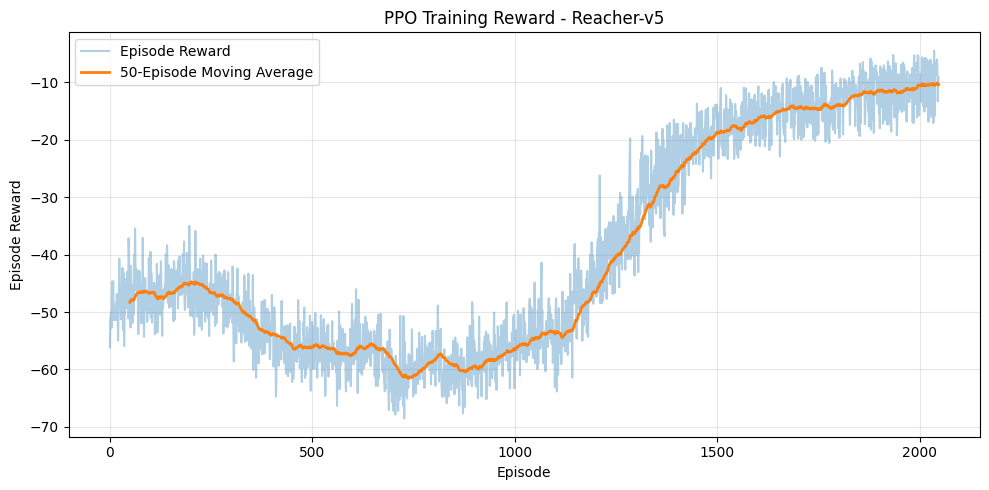

In [35]:
os.makedirs("outputs", exist_ok=True)

reward_series = pd.Series(episode_rewards)

reward_moving_average = reward_series.rolling(
    window=50
).mean()

plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards,
    alpha=0.35,
    label="Episode Reward"
)

plt.plot(
    reward_moving_average,
    linewidth=2,
    label="50-Episode Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.title("PPO Training Reward - Reacher-v5")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "outputs/ppo_episode_reward_curve.png",
    dpi=300
)

plt.show()

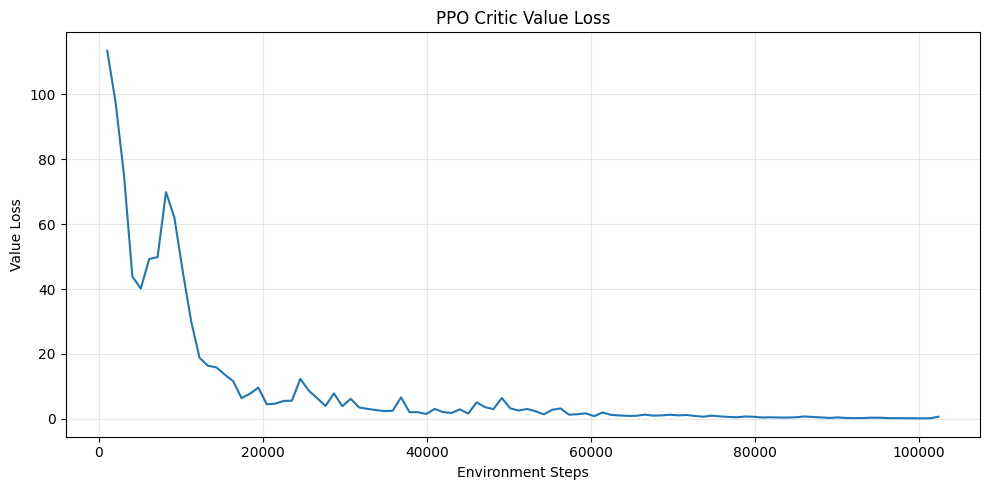

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    training_history["update_steps"],
    value_losses
)

plt.xlabel("Environment Steps")
plt.ylabel("Value Loss")
plt.title("PPO Critic Value Loss")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "outputs/ppo_value_loss_curve.png",
    dpi=300
)

plt.show()

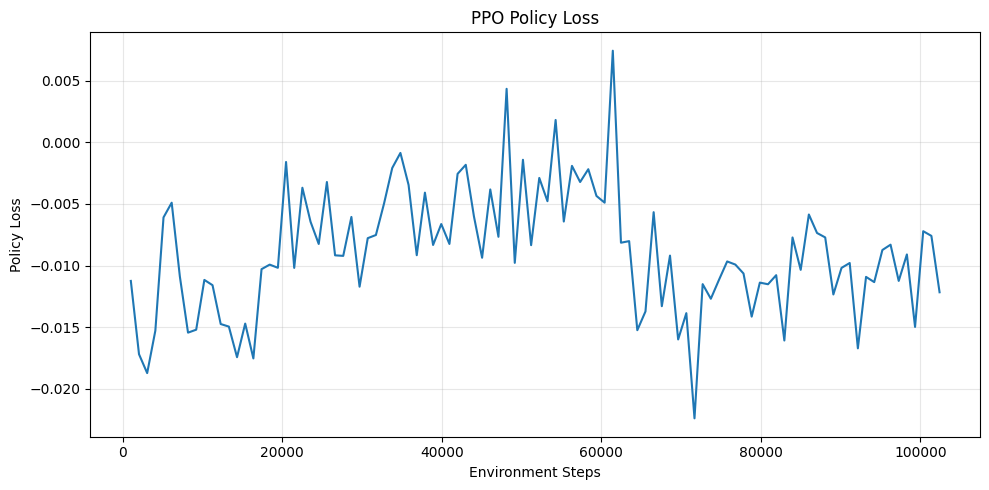

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    training_history["update_steps"],
    policy_losses
)

plt.xlabel("Environment Steps")
plt.ylabel("Policy Loss")
plt.title("PPO Policy Loss")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "outputs/ppo_policy_loss_curve.png",
    dpi=300
)

plt.show()

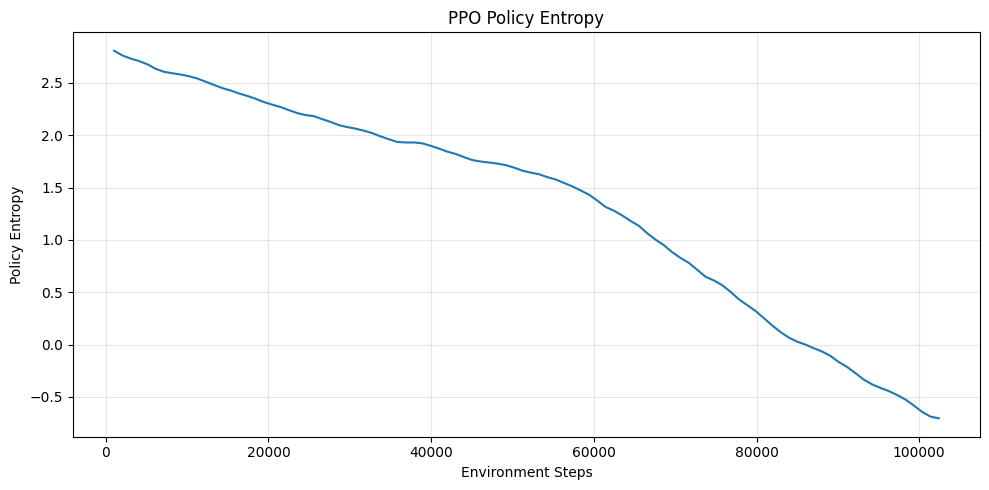

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    training_history["update_steps"],
    entropies
)

plt.xlabel("Environment Steps")
plt.ylabel("Policy Entropy")
plt.title("PPO Policy Entropy")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "outputs/ppo_entropy_curve.png",
    dpi=300
)

plt.show()

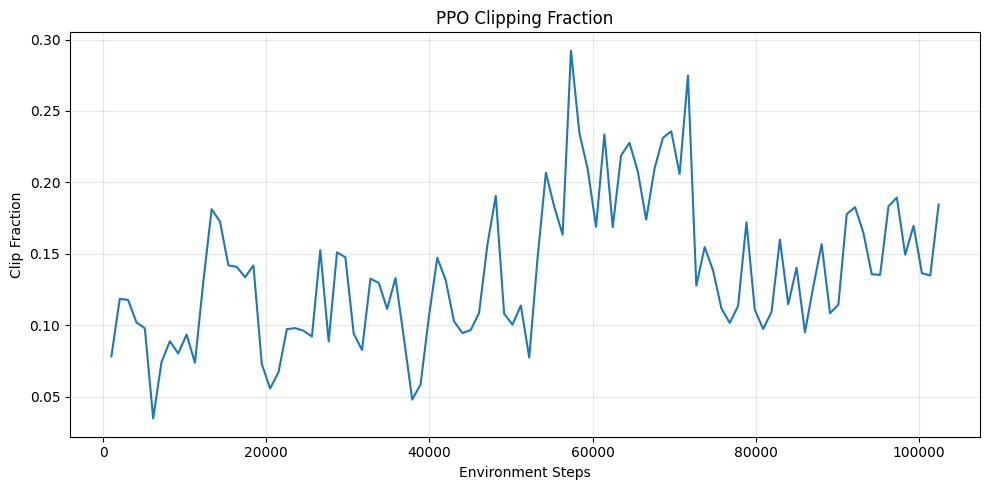

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    training_history["update_steps"],
    clip_fractions
)

plt.xlabel("Environment Steps")
plt.ylabel("Clip Fraction")
plt.title("PPO Clipping Fraction")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "outputs/ppo_clip_fraction_curve.png",
    dpi=300
)

plt.show()

## 14. Final Policy Evaluation

After training, the PPO agent is evaluated without updating the neural network.

During evaluation, the deterministic mean action produced by the actor is used instead of sampling from the Gaussian policy. This removes training-time exploration and provides a clearer measure of the learned policy's performance.

The trained agent is evaluated across multiple Reacher episodes, and its mean, standard deviation, best, and worst episode rewards are reported.

In [40]:
def evaluate_policy(
    env,
    model,
    num_episodes=100,
    seed=1000
):
    evaluation_rewards = []

    for episode in range(num_episodes):

        state, info = env.reset(
            seed=seed + episode
        )

        episode_reward = 0.0
        done = False

        while not done:

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32
            )

            with torch.no_grad():

                action_mean, _, _ = model(
                    state_tensor
                )

                # Deterministic evaluation action
                action = torch.tanh(
                    action_mean
                )

            action_numpy = action.numpy()

            next_state, reward, terminated, truncated, info = env.step(
                action_numpy
            )

            episode_reward += reward

            state = next_state

            done = terminated or truncated

        evaluation_rewards.append(
            episode_reward
        )

    return np.array(
        evaluation_rewards,
        dtype=np.float32
    )

In [41]:
evaluation_rewards = evaluate_policy(
    env=env,
    model=final_model,
    num_episodes=100,
    seed=1000
)

print("=" * 60)
print("FINAL PPO EVALUATION")
print("=" * 60)

print(
    f"Evaluation episodes : "
    f"{len(evaluation_rewards)}"
)

print(
    f"Mean reward         : "
    f"{evaluation_rewards.mean():.4f}"
)

print(
    f"Median reward       : "
    f"{np.median(evaluation_rewards):.4f}"
)

print(
    f"Reward std          : "
    f"{evaluation_rewards.std():.4f}"
)

print(
    f"Best reward         : "
    f"{evaluation_rewards.max():.4f}"
)

print(
    f"Worst reward        : "
    f"{evaluation_rewards.min():.4f}"
)

FINAL PPO EVALUATION
Evaluation episodes : 100
Mean reward         : -6.9970
Median reward       : -6.2484
Reward std          : 3.4764
Best reward         : -1.4447
Worst reward        : -14.3530


## 15. Save Final Model and Results

The trained PPO model, training metrics, and evaluation results are saved as project artifacts.

Saving these outputs allows the trained policy to be reused without retraining and provides numerical evidence for the analysis presented in the lab report.

In [42]:
os.makedirs("checkpoints", exist_ok=True)

checkpoint_path = "checkpoints/ppo_reacher_final.pt"

torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "optimizer_state_dict": final_optimizer.state_dict(),

        "observation_dim": observation_dim,
        "action_dim": action_dim,

        "learning_rate": learning_rate,
        "gamma": gamma,
        "gae_lambda": gae_lambda,
        "clip_epsilon": clip_epsilon,
        "rollout_steps": rollout_steps,
        "batch_size": batch_size,
        "ppo_epochs": ppo_epochs,
        "entropy_coef": entropy_coef,
        "value_coef": value_coef,
        "max_grad_norm": max_grad_norm,

        "total_training_steps": training_history["total_steps"],
        "seed": seed
    },
    checkpoint_path
)

print("Final PPO checkpoint saved:")
print(checkpoint_path)

Final PPO checkpoint saved:
checkpoints/ppo_reacher_final.pt


In [43]:
episode_metrics = pd.DataFrame({
    "episode": np.arange(
        1,
        len(episode_rewards) + 1
    ),
    "reward": episode_rewards
})

episode_metrics.to_csv(
    "outputs/ppo_episode_metrics.csv",
    index=False
)

print(episode_metrics.head())

print(
    "\nEpisode metrics saved:",
    len(episode_metrics),
    "episodes"
)

   episode     reward
0        1 -56.156609
1        2 -51.296497
2        3 -50.624344
3        4 -49.968491
4        5 -52.721985

Episode metrics saved: 2048 episodes


In [44]:
update_metrics = pd.DataFrame({
    "update": np.arange(
        1,
        len(training_history["update_steps"]) + 1
    ),

    "environment_steps":
        training_history["update_steps"],

    "policy_loss":
        training_history["policy_losses"],

    "value_loss":
        training_history["value_losses"],

    "entropy":
        training_history["entropies"],

    "clip_fraction":
        training_history["clip_fractions"]
})

update_metrics.to_csv(
    "outputs/ppo_update_metrics.csv",
    index=False
)

print(update_metrics.head())

print(
    "\nUpdate metrics saved:",
    len(update_metrics),
    "PPO updates"
)

   update  environment_steps  policy_loss  value_loss   entropy  clip_fraction
0       1               1024    -0.011241  113.425892  2.808148       0.078125
1       2               2048    -0.017181   97.494192  2.763331       0.118457
2       3               3072    -0.018713   75.052010  2.733031       0.117676
3       4               4096    -0.015274   43.841204  2.709677       0.101953
4       5               5120    -0.006093   40.151755  2.678262       0.097852

Update metrics saved: 100 PPO updates


In [45]:
evaluation_metrics = pd.DataFrame({
    "episode": np.arange(
        1,
        len(evaluation_rewards) + 1
    ),
    "reward": evaluation_rewards
})

evaluation_metrics.to_csv(
    "outputs/ppo_evaluation_metrics.csv",
    index=False
)

print(
    "Evaluation metrics saved:",
    len(evaluation_metrics),
    "episodes"
)

Evaluation metrics saved: 100 episodes
